## Set Up

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('demographics_data.csv')

In [3]:
df = df.drop(columns=['Unnamed: 0','SEQN'])

In [4]:
df.columns

Index(['SEX', 'AGE', 'RACE', 'CITIZENSHIP', 'EDUCATION', 'MARITAL_STATUS',
       'HH_NUMBER', 'HH_INCOME', 'RATIO_POVERTY', 'Total_Depression_Score',
       'Light', 'Moderate', 'Sedentary', 'DAILY_MEAN_MIMS', 'afternoon',
       'evening', 'morning', 'night', 'AVG_PEAK30_MIMS',
       'AVG_SLEEP_DURATION_MIN', 'SLEEP_DURATION_SD', 'AVG_SLEEP_HOURS',
       'SLEEP_SD_HOURS', 'Avg_wake_bouts'],
      dtype='object')

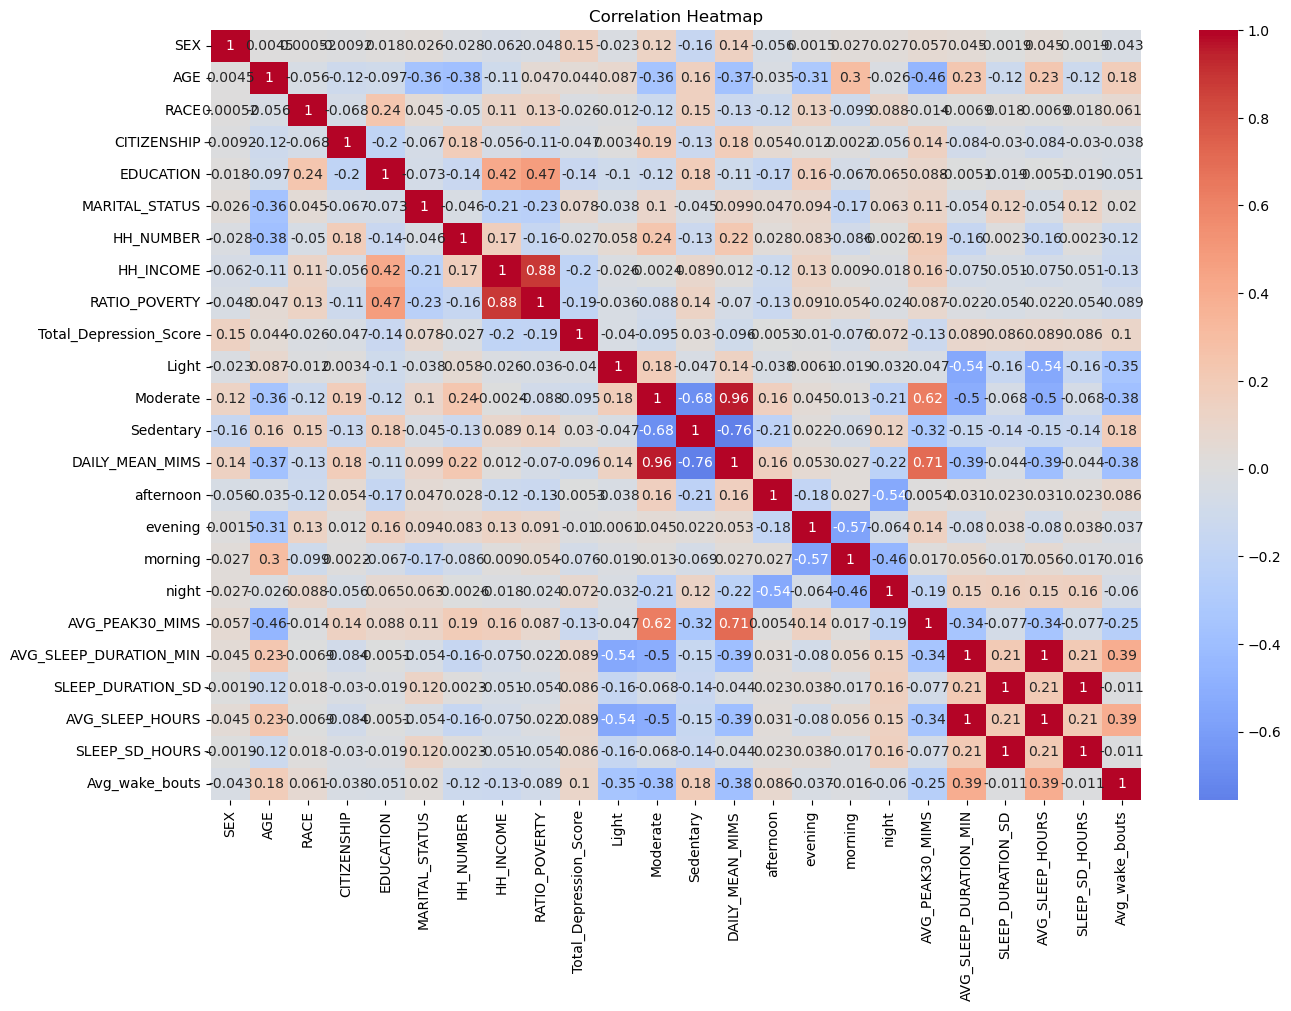

In [5]:
plt.figure(figsize=(15,10))
corr = df.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap")
plt.show()

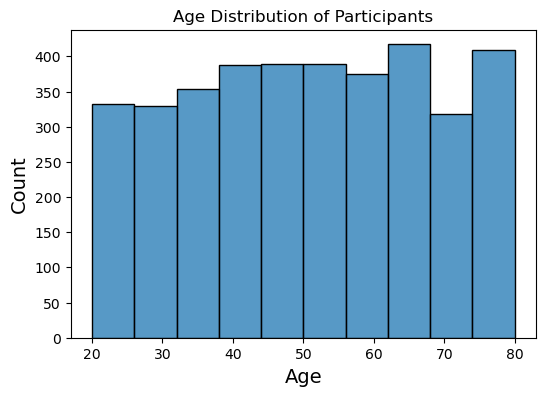

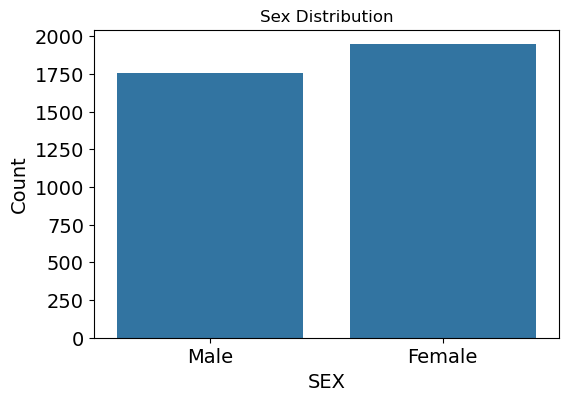

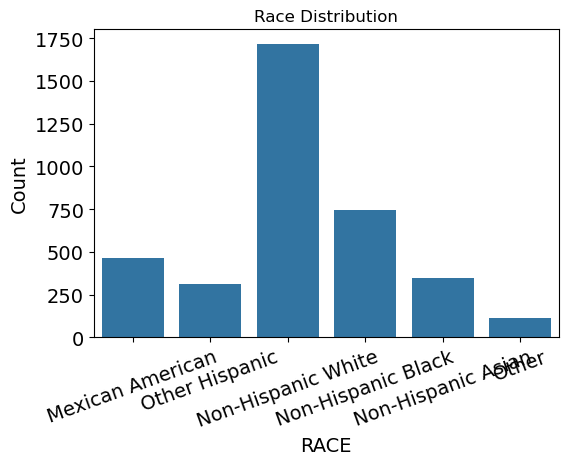

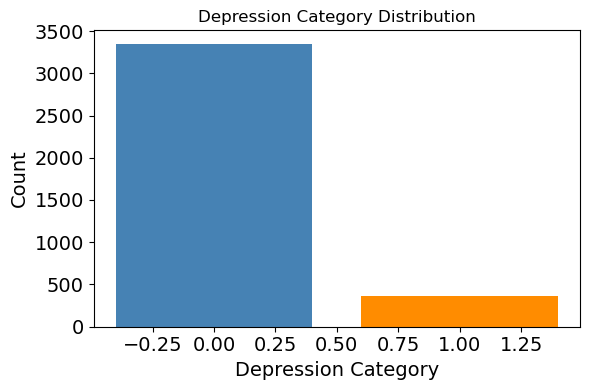

In [6]:
# Example: Age distribution
plt.figure(figsize=(6,4))
sns.histplot(df['AGE'], bins=10, kde=False)
plt.xlabel("Age",fontsize=14)
plt.ylabel("Count",fontsize=14)
plt.title("Age Distribution of Participants")
plt.show()

# Example: Gender distribution
plt.figure(figsize=(6,4))
sns.countplot(x='SEX', data=df)
plt.xlabel("SEX",fontsize=14)
plt.ylabel("Count",fontsize=14)
plt.xticks([0, 1], ["Male", "Female"],fontsize=14)
plt.yticks(fontsize=14)
plt.title("Sex Distribution")
plt.show()

class_mapping = {1: 'Mexican American', 2: 'Other Hispanic', 3:'Non-Hispanic White',4:'Non-Hispanic Black',6:'Non-Hispanic Asian',7:'Other'}
# Example: Race distribution
plt.figure(figsize=(6,4))
sns.countplot(x='RACE', data=df)
plt.xlabel("RACE",fontsize=14)
plt.ylabel("Count",fontsize=14)
plt.xticks([0, 1, 2, 3, 4, 5], ['Mexican American','Other Hispanic','Non-Hispanic White','Non-Hispanic Black','Non-Hispanic Asian','Other'],rotation=20,fontsize=14)
plt.yticks(fontsize=14)
plt.title("Race Distribution")
plt.show()

# Example: Depression distribution
# Create depression category
df['Depression_Category'] = df["Total_Depression_Score"].apply(lambda x: 1 if x >= 10 else 0)

# Count the categories
counts = df['Depression_Category'].value_counts()

# Plot
plt.figure(figsize=(6,4))
plt.bar(
    counts.index,
    counts.values,
    color=["steelblue", "darkorange"]  # two different colors
)

plt.xlabel("Depression Category",fontsize=14)
plt.ylabel("Count",fontsize=14)
plt.title("Depression Category Distribution")
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.show()

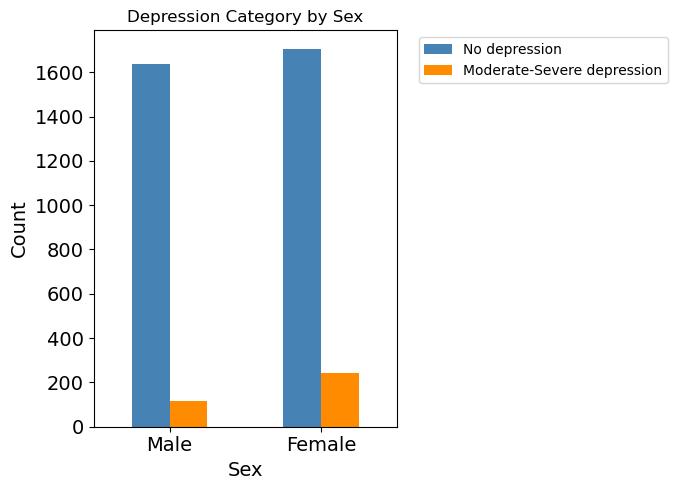

In [7]:
# Compute raw counts instead of proportions
counts = (
    df.groupby("SEX")["Depression_Category"]
      .value_counts()
      .unstack(fill_value=0)
)

# Rename columns
counts.columns = ["No depression", "Moderate-Severe depression"]

# Plot side-by-side bars
counts.plot(kind="bar", stacked=False, figsize=(7,5),
            color=["steelblue", "darkorange"])

plt.ylabel("Count",fontsize=14)
plt.xlabel("Sex",fontsize=14)
plt.title("Depression Category by Sex")
plt.xticks(rotation=0)
plt.xticks([0, 1], ["Male", "Female"],fontsize=14)
plt.yticks(fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

C:\Users\macke\AppData\Local\Temp\ipykernel_25604\2099281399.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("AGE_GROUP")["Depression_Category"]


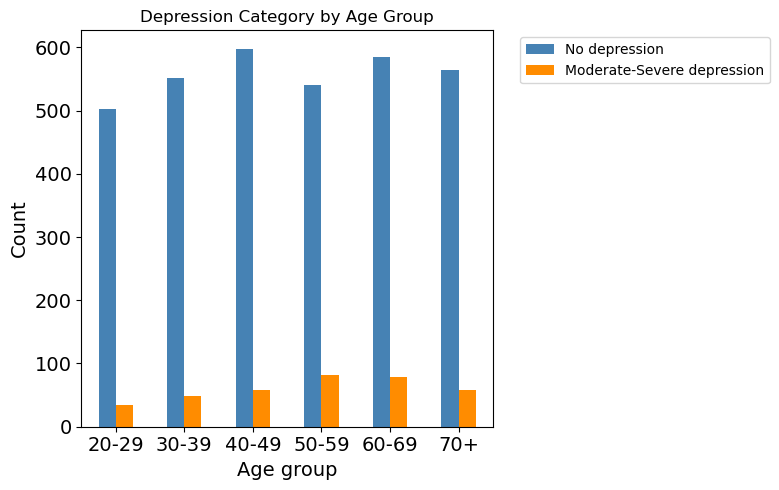

In [8]:
# Create age groups
bins = [20, 30, 40, 50, 60, 70, 120]
labels = ["20-29", "30-39", "40-49", "50-59", "60-69", "70+"]
df["AGE_GROUP"] = pd.cut(df["AGE"], bins=bins, labels=labels, right=False)

# Compute raw counts
counts_age = (
    df.groupby("AGE_GROUP")["Depression_Category"]
      .value_counts()
      .unstack(fill_value=0)
)

counts_age.columns = ["No depression", "Moderate-Severe depression"]

# Plot
counts_age.plot(kind="bar", stacked=False, figsize=(8,5),
                color=["steelblue", "darkorange"])

plt.ylabel("Count",fontsize=14)
plt.xlabel("Age group",fontsize=14)
plt.title("Depression Category by Age Group")
plt.xticks(rotation=0,fontsize=14)
plt.yticks(fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

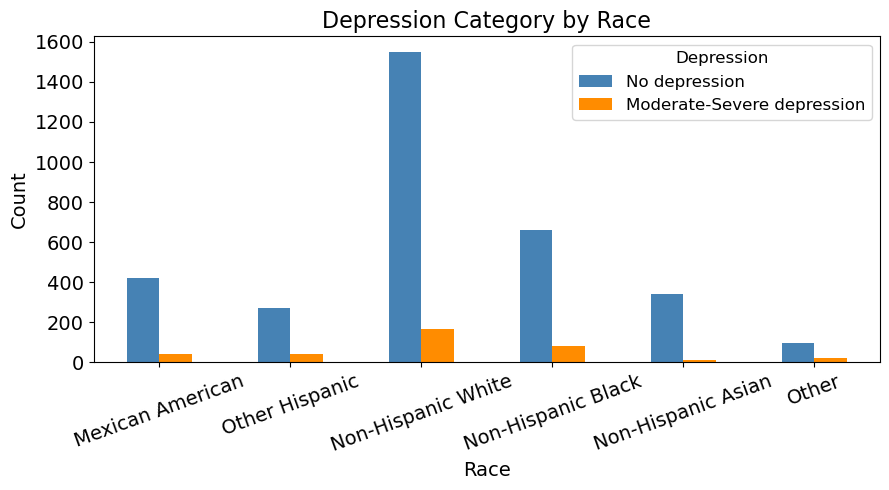

In [9]:
# Compute raw counts
counts_race = (
    df.groupby("RACE")["Depression_Category"]
      .value_counts()
      .unstack(fill_value=0)
)

counts_race.columns = ["No depression", "Moderate-Severe depression"]

# Plot
ax = counts_race.plot(kind="bar", stacked=False, figsize=(9,5),
                      color=["steelblue", "darkorange"])

# Labels and title
plt.ylabel("Count", fontsize=14)
plt.xlabel("Race", fontsize=14)
plt.title("Depression Category by Race", fontsize=16)

plt.xticks(
    ticks=range(len(counts_race.index)),
    labels=['Mexican American','Other Hispanic','Non-Hispanic White',
            'Non-Hispanic Black','Non-Hispanic Asian','Other'],
    rotation=20,
    fontsize=14
)
plt.yticks(fontsize=14)

# Move legend inside the plot
plt.legend(loc='upper right', fontsize=12, title="Depression", title_fontsize=12)

plt.tight_layout()
plt.show()

In [10]:
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis, shapiro

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

In [11]:
# --- VIF-based multicollinearity utilities ---
# Uses training data only (no test leakage) and iteratively drops features with high VIF.

import numpy as np
import pandas as pd

try:
    from IPython.display import display
except Exception:
    # In notebooks, `display` is usually available anyway.
    display = print

try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
except ImportError as e:
    raise ImportError(
        "statsmodels is required for VIF calculations. Install with: pip install statsmodels"
    ) from e


def _clean_for_vif(X):
    """Return numeric, finite, non-constant columns suitable for VIF.

    Notes:
    - Drops rows with any NaN/inf (VIF is regression-based).
    - Drops constant/near-constant columns (VIF undefined).
    """
    if not isinstance(X, pd.DataFrame):
        X = pd.DataFrame(X)

    X_num = X.copy()
    for c in X_num.columns:
        X_num[c] = pd.to_numeric(X_num[c], errors="coerce")

    X_num = X_num.replace([np.inf, -np.inf], np.nan).dropna(axis=0, how="any")

    nunique = X_num.nunique(dropna=False)
    constant_cols = nunique[nunique <= 1].index.tolist()
    if constant_cols:
        X_num = X_num.drop(columns=constant_cols)

    return X_num.astype(float), constant_cols


def vif_table(X):
    """Compute VIF for each column; returns (table, dropped_constant_cols)."""
    X_clean, constant_cols = _clean_for_vif(X)

    if X_clean.shape[1] == 0:
        return pd.DataFrame(columns=["feature", "VIF"]), constant_cols

    values = X_clean.values
    vifs = []
    for i in range(values.shape[1]):
        try:
            v = float(variance_inflation_factor(values, i))
        except Exception:
            v = float("inf")
        vifs.append(v)

    out = (
        pd.DataFrame({"feature": X_clean.columns.tolist(), "VIF": vifs})
        .sort_values("VIF", ascending=False)
        .reset_index(drop=True)
    )
    return out, constant_cols


def select_features_by_vif(X, threshold=10.0, max_iter=10_000):
    """Iteratively drop the single highest-VIF feature until max VIF <= threshold."""
    X_work, constant_cols = _clean_for_vif(X)

    removed = []
    history = []

    if X_work.shape[1] <= 1:
        return {
            "selected": X_work.columns.tolist(),
            "removed": constant_cols,
            "history": history,
            "final_vif": pd.DataFrame(columns=["feature", "VIF"]),
        }

    for _ in range(max_iter):
        tbl, _ = vif_table(X_work)
        if tbl.empty:
            break

        max_vif = float(tbl.loc[0, "VIF"])
        max_feat = str(tbl.loc[0, "feature"])

        history.append(
            {"max_feature": max_feat, "max_vif": max_vif, "n_features": int(X_work.shape[1])}
        )

        if np.isfinite(max_vif) and max_vif <= threshold:
            break

        removed.append(max_feat)
        X_work = X_work.drop(columns=[max_feat])
        if X_work.shape[1] <= 1:
            break

    final_tbl, _ = vif_table(X_work)

    return {
        "selected": X_work.columns.tolist(),
        "removed": constant_cols + removed,
        "history": history,
        "final_vif": final_tbl,
    }


In [12]:
models = {
    "LogReg": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "RandomForest": RandomForestClassifier(class_weight="balanced"),
    "SVM": SVC(probability=True, class_weight="balanced"),
}

models["XGBoost"] = XGBClassifier(
    eval_metric="logloss",
    use_label_encoder=False
)


models["LightGBM"] = LGBMClassifier(class_weight='balanced')

In [13]:
param_grids = {
    "LogReg": {
        "model__C": [0.01, 0.05, 0.1, 0.5, 1, 5, 10],
        "model__penalty": ["l2",None]
    },
    "RandomForest": {
        "model__n_estimators": [100, 150, 200, 250, 300, 400],
        "model__criterion": ["gini","entropy"],
        "model__max_depth": [3, 5, 7, 9, 11, 13, None],
        "model__min_samples_split": [2, 4, 6, 8, 10, 12]
    },
    "SVM": {
        "model__C": [0.01, 0.05, 0.1, 0.5, 1, 5, 10],
        "model__kernel": ["rbf"],
    },
}

param_grids["XGBoost"] = {
    "model__n_estimators": [100, 150, 200, 250, 300, 400],
    "model__max_depth": [3, 5, 7, 9, 11, 13, None],
    "model__learning_rate": [0.0001, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 10]
}

param_grids["LightGBM"] = {
    "model__n_estimators": [100, 150, 200, 250, 300, 400],
    "model__learning_rate": [0.0001, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 10]
}

In [14]:
sampling_strategies = {
    "smote": SMOTE(random_state=42),
    "undersample": RandomUnderSampler(random_state=42),
    "smote_then_under": ("smote_under", SMOTE(random_state=42), RandomUnderSampler(random_state=42)),
}

## Feature Selection

In [15]:
both_features = ['SEX', 'AGE', 'RACE', 'CITIZENSHIP', 'EDUCATION', 'MARITAL_STATUS','HH_NUMBER', 'HH_INCOME', 'RATIO_POVERTY','Light', 'Moderate', 'Sedentary', 'DAILY_MEAN_MIMS', 'afternoon','evening', 'morning', 'night', 'AVG_PEAK30_MIMS', 'AVG_SLEEP_HOURS','SLEEP_SD_HOURS', 'Avg_wake_bouts','Depression_Category']

In [16]:
both_df_features = df[both_features]

In [17]:
# --- VIF feature selection (Combined / All features) ---
# NOTE: You requested VIF to be computed on the full dataset *before splitting*.
# For strict leakage-avoidance, compute VIF on training only.

VIF_THRESHOLD = 10.0

vif_sel_both = select_features_by_vif(both_df_features, threshold=VIF_THRESHOLD)
both_selected = vif_sel_both["selected"]
both_removed = vif_sel_both["removed"]

print(f"VIF threshold: {VIF_THRESHOLD}")
print(f"Selected features ({len(both_selected)}): {both_selected}")
print(f"Removed features ({len(both_removed)}): {both_removed}")
print("\nFinal VIF table (combined):")
display(vif_sel_both["final_vif"])

# Apply selection before split
all_features = both_df_features[both_selected]

VIF threshold: 10.0
Selected features (10): ['SEX', 'AGE', 'RACE', 'MARITAL_STATUS', 'HH_NUMBER', 'RATIO_POVERTY', 'Moderate', 'SLEEP_SD_HOURS', 'Avg_wake_bouts', 'Depression_Category']
Removed features (12): ['DAILY_MEAN_MIMS', 'AVG_SLEEP_HOURS', 'afternoon', 'morning', 'evening', 'HH_INCOME', 'Sedentary', 'AVG_PEAK30_MIMS', 'night', 'Light', 'CITIZENSHIP', 'EDUCATION']

Final VIF table (combined):


,feature,VIF
0,SEX,9.828932
1,Avg_wake_bouts,8.627333
2,AGE,8.506960
3,Moderate,6.173513
4,RACE,6.004094
5,HH_NUMBER,4.631932
6,SLEEP_SD_HOURS,3.662049
7,RATIO_POVERTY,3.445323
8,MARITAL_STATUS,3.204307
9,Depression_Category,1.165353


In [18]:
# Create new features
all_features['circadian_ratio'] = (both_df_features['morning'] + both_df_features['afternoon']) / (both_df_features['evening'] + both_df_features['night'])
all_features['composite_mims'] = both_df_features['AVG_PEAK30_MIMS'] / both_df_features['DAILY_MEAN_MIMS']
all_features['high_v_low'] = both_df_features['Moderate'] / (both_df_features['Light'] + both_df_features['Sedentary'])
all_features['Income_per_person'] = both_df_features['HH_INCOME'] / both_df_features['HH_NUMBER']

C:\Users\macke\AppData\Local\Temp\ipykernel_25604\3688569826.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_features['circadian_ratio'] = (both_df_features['morning'] + both_df_features['afternoon']) / (both_df_features['evening'] + both_df_features['night'])
C:\Users\macke\AppData\Local\Temp\ipykernel_25604\3688569826.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_features['composite_mims'] = both_df_features['AVG_PEAK30_MIMS'] / both_df_features['DAILY_MEAN_MIMS']
C:\Users\macke\AppData\

In [19]:
# Remove moderate
all_features = all_features.drop(columns=['Moderate','HH_NUMBER'])

In [20]:
# TARGET
y_both = all_features["Depression_Category"]

# ALL predictors
X_both = all_features.drop(columns=["Depression_Category"])

normal_vars_both = []
minmax_vars_both = []
robust_vars_both = []

for feat in X_both.columns:
    x = all_features[feat].dropna().values

    # 1. Shapiro normality test
    p_norm = shapiro(x)[1]

    # 2. Skewness
    sk = skew(x)

    # 3. Outlier ratio using IQR
    q1, q3 = np.percentile(x, [25, 75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_ratio = np.mean((x < lower) | (x > upper))

    if feat in ['Light', 'Moderate', 'Sedentary', 'DAILY_MEAN_MIMS', 'afternoon', 'evening', 'morning', 'AVG_SLEEP_HOURS', 'Avg_wake_bouts','night', 'AVG_PEAK30_MIMS', 'SLEEP_SD_HOURS','AGE','RATIO_POVERTY', 'Income_per_person', 'circadian_ratio', 'composite_mims', 'high_v_low']:
        # --- Decision rules ---
        if p_norm > 0.05:  
            # approximately normal
            normal_vars_both.append(feat)

        elif abs(sk) >= 2 or outlier_ratio > 0.05:
            # heavy skew or many outliers → use RobustScaler
            robust_vars_both.append(feat)

        else:
            # non-normal but not extreme → use MinMaxScaler
            minmax_vars_both.append(feat)
    else:
        pass

print("StandardScaler vars:", normal_vars_both)
print("MinMaxScaler vars:", minmax_vars_both)
print("RobustScaler vars:", robust_vars_both)

StandardScaler vars: []
MinMaxScaler vars: ['AGE', 'RATIO_POVERTY', 'Avg_wake_bouts', 'circadian_ratio', 'composite_mims', 'high_v_low', 'Income_per_person']
RobustScaler vars: ['SLEEP_SD_HOURS']


## Only Accelerometer

In [21]:
features = ['SLEEP_SD_HOURS', 'Avg_wake_bouts', 'circadian_ratio', 'composite_mims', 'high_v_low', 'Depression_Category']

In [22]:
df_features = all_features[features]

In [23]:
# TARGET
y = df_features["Depression_Category"]

# ALL predictors
X = df_features.drop(columns=["Depression_Category"])

normal_vars = []
minmax_vars = []
robust_vars = []

for feat in X.columns:
    if feat in normal_vars_both:
        normal_vars.append(feat)
    elif feat in minmax_vars_both:
        minmax_vars.append(feat)
    elif feat in robust_vars_both:
        robust_vars.append(feat)
    else:
        pass

print("StandardScaler vars:", normal_vars)
print("MinMaxScaler vars:", minmax_vars)
print("RobustScaler vars:", robust_vars)

StandardScaler vars: []
MinMaxScaler vars: ['Avg_wake_bouts', 'circadian_ratio', 'composite_mims', 'high_v_low']
RobustScaler vars: ['SLEEP_SD_HOURS']


In [24]:
preprocess = ColumnTransformer(
    transformers=[
        ("zscore", StandardScaler(), normal_vars),
        ("minmax", MinMaxScaler(), minmax_vars),
        ("robust", RobustScaler(), robust_vars)
    ],
    remainder="passthrough"
)

In [25]:
# 80% train, 20% temp
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.10, stratify=y, random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (3330, 5)
Test: (370, 5)


In [26]:
# Keep stable copies for later export/fairness cells (prevents X_test being overwritten later)
X_train_accel = X_train.copy()
X_test_accel = X_test.copy()
y_train_accel = y_train.copy()
y_test_accel = y_test.copy()


In [27]:
# Train using no sampling strategy (baseline)
results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for name, model in models.items():
    print(f"Training {name} with no sampling...")
    pipe = ImbPipeline([("preprocess", preprocess), ("model", model)])

    grid = GridSearchCV(
        pipe,
        param_grids[name],
        scoring='f1',
        cv=cv,
        n_jobs=-1,
        verbose=2
    )

    grid.fit(X_train, y_train)

    print("Best params:", grid.best_params_)
    print("Best CV F1:", grid.best_score_)

    # Save result
    results[(name)] = grid

Training LogReg with no sampling...
Fitting 5 folds for each of 14 candidates, totalling 70 fits
Best params: {'model__C': 0.5, 'model__penalty': 'l2'}
Best CV F1: 0.21514538705625955
Training RandomForest with no sampling...
Fitting 5 folds for each of 504 candidates, totalling 2520 fits
Best params: {'model__criterion': 'gini', 'model__max_depth': 3, 'model__min_samples_split': 12, 'model__n_estimators': 100}
Best CV F1: 0.216757409275375
Training SVM with no sampling...
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Best params: {'model__C': 0.5, 'model__kernel': 'rbf'}
Best CV F1: 0.2147407019907019
Training XGBoost with no sampling...
Fitting 5 folds for each of 378 candidates, totalling 1890 fits


c:\Users\macke\anaconda3\envs\torch_env\lib\site-packages\xgboost\training.py:199: UserWarning: [14:43:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best params: {'model__learning_rate': 10, 'model__max_depth': None, 'model__n_estimators': 100}
Best CV F1: 0.16426167082883747
Training LightGBM with no sampling...
Fitting 5 folds for each of 54 candidates, totalling 270 fits
[LightGBM] [Info] Number of positive: 323, number of negative: 3007
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000123 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1195
[LightGBM] [Info] Number of data points in the train set: 3330, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Best params: {'model__learning_rate': 0.001, 'model__n_estimators': 200}
Best CV F1: 0.20422734769323764


In [28]:
import numpy as np
import json
import joblib
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    classification_report,
)

# --------------------------------------------------
# Final test‑set evaluation
# --------------------------------------------------

def evaluate_on_test(best_estimator, X_test, y_test, pos_label=0):
    """
    Evaluate a trained estimator on the held‑out test set.
    """
    y_pred = best_estimator.predict(X_test)

    if hasattr(best_estimator, "predict_proba"):
        y_prob = best_estimator.predict_proba(X_test)[:, 1]
        auroc = float(roc_auc_score(y_test, y_prob))
    else:
        y_prob = None
        auroc = None

    return {
        "f1": float(f1_score(y_test, y_pred, pos_label=pos_label)),
        "precision": float(
            precision_score(y_test, y_pred, pos_label=pos_label, zero_division=0)
        ),
        "recall": float(
            recall_score(y_test, y_pred, pos_label=pos_label, zero_division=0)
        ),
        "auroc": auroc,
        "specificity": float(
            recall_score(y_test, y_pred, pos_label=1, zero_division=0)
        ),

        "y_pred": y_pred,
        "y_prob": y_prob,
    }

# --------------------------------------------------
# Select best model (already tuned on training data)
# --------------------------------------------------

best_combo = max(results, key=lambda k: results[k].best_score_)
best_model = results[best_combo].best_estimator_

print("Best model:", best_combo)
print("Best parameters:", results[best_combo].best_params_)

# --------------------------------------------------
# Evaluate ONCE on the held‑out test set
# --------------------------------------------------

test_eval = evaluate_on_test(
    best_model,
    X_test,
    y_test,
    pos_label=0,  # keep consistent with your original choice
)

print("\nFinal Test‑Set Classification Report:")
print(classification_report(y_test, test_eval["y_pred"]))

print("Final Test‑Set Metrics:")
print(f"F1 (pos label = 0): {test_eval['f1']:.4f}")
print(f"Precision: {test_eval['precision']:.4f}")
print(f"Recall: {test_eval['recall']:.4f}")
print(f"AUROC: {test_eval['auroc']:.4f}" if test_eval["auroc"] is not None else "AUROC: N/A")

# --------------------------------------------------
# Save model and FINAL test‑set results
# --------------------------------------------------

joblib.dump(
    {
        "model": best_model,
        "model_name": best_combo,
        "best_params": results[best_combo].best_params_,
        "test_metrics": {
            "f1": test_eval["f1"],
            "precision": test_eval["precision"],
            "recall": test_eval["recall"],
            "auroc": test_eval["auroc"],
            "specificity": test_eval["specificity"],
        },
    },
    "accel_best_model.pkl",
)

with open("accel_best_model_info.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "model": best_combo,
            "parameters": results[best_combo].best_params_,
            "final_test_metrics": {
                "f1": test_eval["f1"],
                "precision": test_eval["precision"],
                "recall": test_eval["recall"],
                "auroc": test_eval["auroc"],
                "specificity": test_eval["specificity"],

            },
        },
        f,
        indent=2,
    )

Best model: RandomForest
Best parameters: {'model__criterion': 'gini', 'model__max_depth': 3, 'model__min_samples_split': 12, 'model__n_estimators': 100}

Final Test‑Set Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.67      0.77       334
           1       0.12      0.42      0.19        36

    accuracy                           0.65       370
   macro avg       0.52      0.54      0.48       370
weighted avg       0.84      0.65      0.72       370

Final Test‑Set Metrics:
F1 (pos label = 0): 0.7737
Precision: 0.9143
Recall: 0.6707
AUROC: 0.6249


In [29]:
results[best_combo].best_params_

{'model__criterion': 'gini',
 'model__max_depth': 3,
 'model__min_samples_split': 12,
 'model__n_estimators': 100}

In [31]:
sampling_strategies

{'smote': SMOTE(random_state=42),
 'undersample': RandomUnderSampler(random_state=42),
 'smote_then_under': ('smote_under',
  SMOTE(random_state=42),
  RandomUnderSampler(random_state=42))}

In [32]:
# Using the same model, find the best sampling strategy for the accelerometer-only features
# Train using no sampling strategy (baseline)
sampling_results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
name = best_combo
param_list = {key: [value] for key, value in results[best_combo].best_params_.items()}
for samp_name, sampler in sampling_strategies.items():
    print(f"Training {samp_name}...")
    # Build pipeline depending on sampler type
    if samp_name == "smote_then_under":
        sm, us = sampler[1], sampler[2]
        pipe = ImbPipeline([
            ("preprocess", preprocess),
            ("smote", sm),
            ("under", us),
            ("model", models[best_combo])
        ])
    else:
        pipe = ImbPipeline([
            ("preprocess", preprocess),
            ("sampler", sampler),
            ("model", models[best_combo])
        ])

    # Perform cross validation with no grid search (just to evaluate the sampling strategy with the fixed model)
    grid = GridSearchCV(
        pipe,
        param_list,  # use the same hyperparameters as the best model
        scoring='f1',
        cv=cv,
        n_jobs=-1,
        verbose=2
    )

    grid.fit(X_train, y_train)

    print("Best params:", grid.best_params_)
    print("Best CV F1:", grid.best_score_)

    # Save result
    sampling_results[samp_name] = grid


Training smote...
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best params: {'model__criterion': 'gini', 'model__max_depth': 3, 'model__min_samples_split': 12, 'model__n_estimators': 100}
Best CV F1: 0.19760515845006044
Training undersample...
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best params: {'model__criterion': 'gini', 'model__max_depth': 3, 'model__min_samples_split': 12, 'model__n_estimators': 100}
Best CV F1: 0.2088686615212724
Training smote_then_under...
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best params: {'model__criterion': 'gini', 'model__max_depth': 3, 'model__min_samples_split': 12, 'model__n_estimators': 100}
Best CV F1: 0.20004520460305222


In [34]:
import json
import joblib
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    classification_report,
)

# --------------------------------------------------
# Helper: final test‑set evaluation ONLY
# --------------------------------------------------

def evaluate_on_test(best_estimator, X_test, y_test, pos_label=0):
    y_pred = best_estimator.predict(X_test)

    if hasattr(best_estimator, "predict_proba"):
        y_prob = best_estimator.predict_proba(X_test)[:, 1]
        auroc = float(roc_auc_score(y_test, y_prob))
    else:
        y_prob = None
        auroc = None

    return {
        "f1": float(f1_score(y_test, y_pred, pos_label=pos_label)),
        "precision": float(
            precision_score(y_test, y_pred, pos_label=pos_label, zero_division=0)
        ),
        "recall": float(
            recall_score(y_test, y_pred, pos_label=pos_label, zero_division=0)
        ),
        "auroc": auroc,
        "specificity": float(
            recall_score(y_test, y_pred, pos_label=1, zero_division=0)
        ),
        "y_pred": y_pred,
        "y_prob": y_prob,
    }

# --------------------------------------------------
# Select best model + sampling (based on TRAINING CV)
# --------------------------------------------------

best_sampling = max(
    sampling_results, key=lambda k: sampling_results[k].best_score_
)
best_model = sampling_results[best_sampling].best_estimator_
model_name = best_combo  # already selected model family

print("Best model and sampling (overall):", (model_name, best_sampling))
print("Best parameters:", sampling_results[best_sampling].best_params_)

# --------------------------------------------------
# FINAL evaluation on held‑out test set (ONCE)
# --------------------------------------------------

test_eval = evaluate_on_test(
    best_model,
    X_test,
    y_test,
    pos_label=0,  # keep consistent with earlier reporting
)

print("\nFinal Test‑Set Classification Report:")
print(classification_report(y_test, test_eval["y_pred"]))

print("Final Test‑Set Metrics:")
print(f"F1 (pos label = 0): {test_eval['f1']:.4f}")
print(f"Precision: {test_eval['precision']:.4f}")
print(f"Recall: {test_eval['recall']:.4f}")
print(
    f"AUROC: {test_eval['auroc']:.4f}"
    if test_eval["auroc"] is not None
    else "AUROC: N/A"
)

# --------------------------------------------------
# Save final model + FINAL test‑set metrics
# --------------------------------------------------

joblib.dump(
    {
        "model": best_model,
        "model_name": model_name,
        "sampling": best_sampling,
        "best_params": sampling_results[best_sampling].best_params_,
        "final_test_metrics": {
            "f1": test_eval["f1"],
            "precision": test_eval["precision"],
            "recall": test_eval["recall"],
            "auroc": test_eval["auroc"],
            "specificity": test_eval["specificity"],
        },
    },
    "accel_best_model_sampling.pkl",
)

with open(
    "accel_best_model_sampling_info.json", "w", encoding="utf-8"
) as f:
    json.dump(
        {
            "model": model_name,
            "sampling": best_sampling,
            "parameters": sampling_results[best_sampling].best_params_,
            "final_test_metrics": {
                "f1": test_eval["f1"],
                "precision": test_eval["precision"],
                "recall": test_eval["recall"],
                "auroc": test_eval["auroc"],
                "specificity": test_eval["specificity"],
            },
        },
        f,
        indent=2,
    )

Best model and sampling (overall): ('RandomForest', 'undersample')
Best parameters: {'model__criterion': 'gini', 'model__max_depth': 3, 'model__min_samples_split': 12, 'model__n_estimators': 100}

Final Test‑Set Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.64      0.76       334
           1       0.15      0.58      0.24        36

    accuracy                           0.64       370
   macro avg       0.54      0.61      0.50       370
weighted avg       0.86      0.64      0.71       370

Final Test‑Set Metrics:
F1 (pos label = 0): 0.7602
Precision: 0.9345
Recall: 0.6407
AUROC: 0.6372


## Only demographics

In [35]:
demo_features = ['AGE', 'RACE', 'RATIO_POVERTY', 'MARITAL_STATUS', 'Income_per_person', 'Depression_Category']

In [36]:
demo_df_features = all_features[demo_features]

In [37]:
# TARGET
y_demo = demo_df_features["Depression_Category"]

# ALL predictors
X_demo = demo_df_features.drop(columns=["Depression_Category"])

normal_vars_demo = []
minmax_vars_demo = []
robust_vars_demo = []

for feat in X_demo.columns:
    if feat in normal_vars_both:
        normal_vars_demo.append(feat)
    elif feat in minmax_vars_both:
        minmax_vars_demo.append(feat)
    elif feat in robust_vars_both:
        robust_vars_demo.append(feat)
    else:
        pass

print("StandardScaler vars:", normal_vars_demo)
print("MinMaxScaler vars:", minmax_vars_demo)
print("RobustScaler vars:", robust_vars_demo)

StandardScaler vars: []
MinMaxScaler vars: ['AGE', 'RATIO_POVERTY', 'Income_per_person']
RobustScaler vars: []


In [38]:
preprocess_demo = ColumnTransformer(
    transformers=[
        ("zscore", StandardScaler(), normal_vars_demo),
        ("minmax", MinMaxScaler(), minmax_vars_demo),
        ("robust", RobustScaler(), robust_vars_demo)
    ],
    remainder="passthrough"
 )

In [39]:
# 80% train, 20% temp
X_train_demo, X_test_demo, y_train_demo, y_test_demo = train_test_split(
    X_demo, y_demo, test_size=0.10, stratify=y_demo, random_state=42
)

print("Train:", X_train_demo.shape)
print("Test:", X_test_demo.shape)

Train: (3330, 5)
Test: (370, 5)


In [40]:
# Keep stable copies for later export/fairness cells
X_train_demo_stable = X_train_demo.copy()
X_test_demo_stable = X_test_demo.copy()
y_train_demo_stable = y_train_demo.copy()
y_test_demo_stable = y_test_demo.copy()


In [41]:
# Train using no sampling strategy (baseline)
results_demo = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for name, model in models.items():
    print(f"Training {name} with no sampling...")
    pipe = ImbPipeline([("preprocess", preprocess_demo), ("model", model)])

    grid = GridSearchCV(
        pipe,
        param_grids[name],
        scoring='f1',
        cv=cv,
        n_jobs=-1,
        verbose=2
    )
    grid.fit(X_train_demo_stable, y_train_demo_stable)

    print("Best params:", grid.best_params_)
    print("Best CV F1:", grid.best_score_)

    # Save result
    results_demo[(name)] = grid

Training LogReg with no sampling...
Fitting 5 folds for each of 14 candidates, totalling 70 fits
Best params: {'model__C': 0.05, 'model__penalty': 'l2'}
Best CV F1: 0.23760411260266406
Training RandomForest with no sampling...
Fitting 5 folds for each of 504 candidates, totalling 2520 fits
Best params: {'model__criterion': 'entropy', 'model__max_depth': 7, 'model__min_samples_split': 10, 'model__n_estimators': 300}
Best CV F1: 0.26608304534432164
Training SVM with no sampling...
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Best params: {'model__C': 10, 'model__kernel': 'rbf'}
Best CV F1: 0.24799851049339633
Training XGBoost with no sampling...
Fitting 5 folds for each of 378 candidates, totalling 1890 fits


c:\Users\macke\anaconda3\envs\torch_env\lib\site-packages\xgboost\training.py:199: UserWarning: [14:47:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best params: {'model__learning_rate': 1, 'model__max_depth': 13, 'model__n_estimators': 300}
Best CV F1: 0.14871175523349436
Training LightGBM with no sampling...
Fitting 5 folds for each of 54 candidates, totalling 270 fits
[LightGBM] [Info] Number of positive: 323, number of negative: 3007
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000144 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 365
[LightGBM] [Info] Number of data points in the train set: 3330, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Best params: {'model__learning_rate': 0.005, 'model__n_estimators': 250}
Best CV F1: 0.256115244480511


In [42]:
import json
import joblib
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    classification_report,
)

# --------------------------------------------------
# Select best model (based on TRAINING CV results)
# --------------------------------------------------

best_combo = max(results_demo, key=lambda k: results_demo[k].best_score_)
best_model = results_demo[best_combo].best_estimator_

print("Best model (no sampling):", best_combo)
print("Best parameters:", results_demo[best_combo].best_params_)

# --------------------------------------------------
# FINAL evaluation on held‑out test set (ONCE)
# --------------------------------------------------

test_eval = evaluate_on_test(
    best_model,
    X_test_demo,
    y_test_demo,
    pos_label=0,  # keep consistent with prior reporting
)

print("\nFinal Test‑Set Classification Report:")
print(classification_report(y_test_demo, test_eval["y_pred"]))

print("Final Test‑Set Metrics:")
print(f"F1 (pos label = 0): {test_eval['f1']:.4f}")
print(f"Precision: {test_eval['precision']:.4f}")
print(f"Recall: {test_eval['recall']:.4f}")
print(
    f"AUROC: {test_eval['auroc']:.4f}"
    if test_eval["auroc"] is not None
    else "AUROC: N/A"
)

# --------------------------------------------------
# Save final model + FINAL test‑set metrics
# --------------------------------------------------

joblib.dump(
    {
        "model": best_model,
        "model_name": best_combo,
        "sampling": None,
        "best_params": results_demo[best_combo].best_params_,
        "final_test_metrics": {
            "f1": test_eval["f1"],
            "precision": test_eval["precision"],
            "recall": test_eval["recall"],
            "auroc": test_eval["auroc"],
            "specificity": test_eval["specificity"],
        },
    },
    "demo_best_model.pkl",
)

with open("demo_best_model_info.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "model": best_combo,
            "sampling": None,
            "parameters": results_demo[best_combo].best_params_,
            "final_test_metrics": {
                "f1": test_eval["f1"],
                "precision": test_eval["precision"],
                "recall": test_eval["recall"],
                "auroc": test_eval["auroc"],
                "specificity": test_eval["specificity"],
            },
        },
        f,
        indent=2,
    )

Best model (no sampling): RandomForest
Best parameters: {'model__criterion': 'entropy', 'model__max_depth': 7, 'model__min_samples_split': 10, 'model__n_estimators': 300}

Final Test‑Set Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.72      0.81       334
           1       0.15      0.47      0.23        36

    accuracy                           0.69       370
   macro avg       0.54      0.59      0.52       370
weighted avg       0.85      0.69      0.75       370

Final Test‑Set Metrics:
F1 (pos label = 0): 0.8074
Precision: 0.9264
Recall: 0.7156
AUROC: 0.6707


In [43]:
results_demo[best_combo].best_params_

{'model__criterion': 'entropy',
 'model__max_depth': 7,
 'model__min_samples_split': 10,
 'model__n_estimators': 300}

In [45]:
# Using the same model, find the best sampling strategy for the accelerometer-only features
# Train using no sampling strategy (baseline)
sampling_results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
name = best_combo
param_list = {key: [value] for key, value in results_demo[best_combo].best_params_.items()}
for samp_name, sampler in sampling_strategies.items():
    print(f"Training {samp_name}...")
    # Build pipeline depending on sampler type
    if samp_name == "smote_then_under":
        sm, us = sampler[1], sampler[2]
        pipe = ImbPipeline([
            ("preprocess", preprocess_demo),
            ("smote", sm),
            ("under", us),
            ("model", models[best_combo])
        ])
    else:
        pipe = ImbPipeline([
            ("preprocess", preprocess_demo),
            ("sampler", sampler),
            ("model", models[best_combo])
        ])

    # Perform cross validation with no grid search (just to evaluate the sampling strategy with the fixed model)
    grid = GridSearchCV(
        pipe,
        param_list,  # use the same hyperparameters as the best model
        scoring='f1',
        cv=cv,
        n_jobs=-1,
        verbose=2
    )

    grid.fit(X_train_demo, y_train_demo)

    print("Best params:", grid.best_params_)
    print("Best CV F1:", grid.best_score_)

    # Save result
    sampling_results[samp_name] = grid


Training smote...
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best params: {'model__criterion': 'entropy', 'model__max_depth': 7, 'model__min_samples_split': 10, 'model__n_estimators': 300}
Best CV F1: 0.25064272575029123
Training undersample...
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best params: {'model__criterion': 'entropy', 'model__max_depth': 7, 'model__min_samples_split': 10, 'model__n_estimators': 300}
Best CV F1: 0.24198492150486053
Training smote_then_under...
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best params: {'model__criterion': 'entropy', 'model__max_depth': 7, 'model__min_samples_split': 10, 'model__n_estimators': 300}
Best CV F1: 0.24897767534991916


In [47]:
import json
import joblib
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    classification_report,
)

# --------------------------------------------------
# Helper: FINAL test‑set evaluation only
# --------------------------------------------------

# --------------------------------------------------
# Select best model + sampling (TRAINING CV only)
# --------------------------------------------------

best_sampling = max(
    sampling_results, key=lambda k: sampling_results[k].best_score_
)
best_model = sampling_results[best_sampling].best_estimator_
model_name = best_combo

print("Best model and sampling:", (model_name, best_sampling))
print("Best parameters:", sampling_results[best_sampling].best_params_)

# --------------------------------------------------
# FINAL evaluation on held‑out demo test set
# --------------------------------------------------

test_eval = evaluate_on_test(
    best_model,
    X_test_demo,
    y_test_demo,
    pos_label=0,  # consistent with original intent
)

print("\nFinal Test‑Set Classification Report:")
print(classification_report(y_test_demo, test_eval["y_pred"]))

print("Final Test‑Set Metrics:")
print(f"F1 (pos label = 0): {test_eval['f1']:.4f}")
print(f"Precision: {test_eval['precision']:.4f}")
print(f"Recall: {test_eval['recall']:.4f}")
print(
    f"AUROC: {test_eval['auroc']:.4f}"
    if test_eval["auroc"] is not None
    else "AUROC: N/A"
)

# --------------------------------------------------
# Save final model + FINAL test metrics
# --------------------------------------------------

joblib.dump(
    {
        "model": best_model,
        "model_name": model_name,
        "sampling": best_sampling,
        "best_params": sampling_results[best_sampling].best_params_,
        "final_test_metrics": {
            "f1": test_eval["f1"],
            "precision": test_eval["precision"],
            "recall": test_eval["recall"],
            "auroc": test_eval["auroc"],
            "specificity": test_eval["specificity"],
        },
    },
    "demo_best_model_sampling.pkl",
)

with open(
    "demo_best_model_sampling_info.json", "w", encoding="utf-8"
) as f:
    json.dump(
        {
            "model": model_name,
            "sampling": best_sampling,
            "parameters": sampling_results[best_sampling].best_params_,
            "final_test_metrics": {
                "f1": test_eval["f1"],
                "precision": test_eval["precision"],
                "recall": test_eval["recall"],
                "auroc": test_eval["auroc"],
                "specificity": test_eval["specificity"],
            },
        },
        f,
        indent=2,
    )

Best model and sampling: ('RandomForest', 'smote')
Best parameters: {'model__criterion': 'entropy', 'model__max_depth': 7, 'model__min_samples_split': 10, 'model__n_estimators': 300}

Final Test‑Set Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.69      0.79       334
           1       0.15      0.50      0.23        36

    accuracy                           0.67       370
   macro avg       0.54      0.59      0.51       370
weighted avg       0.85      0.67      0.73       370

Final Test‑Set Metrics:
F1 (pos label = 0): 0.7883
Precision: 0.9271
Recall: 0.6856
AUROC: 0.6669


## All Features

In [48]:
# TARGET
y_demo = all_features["Depression_Category"]

# ALL predictors
X_demo = all_features.drop(columns=["Depression_Category"])

In [49]:
preprocess_both = ColumnTransformer(
    transformers=[
        ("zscore", StandardScaler(), normal_vars_both),
        ("minmax", MinMaxScaler(), minmax_vars_both),
        ("robust", RobustScaler(), robust_vars_both)
    ],
    remainder="passthrough"
 )

In [50]:
# 80% train, 20% temp
X_train_both, X_test_both, y_train_both, y_test_both = train_test_split(
    X_both, y_both, test_size=0.10, stratify=y_both, random_state=42
)

print("Train:", X_train_both.shape)
print("Test:", X_test_both.shape)

Train: (3330, 11)
Test: (370, 11)


In [51]:
# Keep stable copies for later export/fairness cells
X_train_combined = X_train_both.copy()
X_test_combined = X_test_both.copy()
y_train_combined = y_train_both.copy()
y_test_combined = y_test_both.copy()

In [52]:
# Train using no sampling strategy (baseline)
results_combined = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for name, model in models.items():
    print(f"Training {name} with no sampling...")
    pipe = ImbPipeline([("preprocess", preprocess_both), ("model", model)])

    grid = GridSearchCV(
        pipe,
        param_grids[name],
        scoring='f1',
        cv=cv,
        n_jobs=-1,
        verbose=2
    )
    grid.fit(X_train_both, y_train_both)

    print("Best params:", grid.best_params_)
    print("Best CV F1:", grid.best_score_)

    # Save result
    results_combined[(name)] = grid

Training LogReg with no sampling...
Fitting 5 folds for each of 14 candidates, totalling 70 fits
Best params: {'model__C': 0.1, 'model__penalty': 'l2'}
Best CV F1: 0.26399529475641226
Training RandomForest with no sampling...
Fitting 5 folds for each of 504 candidates, totalling 2520 fits
Best params: {'model__criterion': 'entropy', 'model__max_depth': 5, 'model__min_samples_split': 6, 'model__n_estimators': 150}
Best CV F1: 0.2774221767003256
Training SVM with no sampling...
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Best params: {'model__C': 5, 'model__kernel': 'rbf'}
Best CV F1: 0.2650009602217449
Training XGBoost with no sampling...
Fitting 5 folds for each of 378 candidates, totalling 1890 fits


c:\Users\macke\anaconda3\envs\torch_env\lib\site-packages\xgboost\training.py:199: UserWarning: [14:54:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best params: {'model__learning_rate': 10, 'model__max_depth': 13, 'model__n_estimators': 100}
Best CV F1: 0.14997458786496626
Training LightGBM with no sampling...
Fitting 5 folds for each of 54 candidates, totalling 270 fits
[LightGBM] [Info] Number of positive: 323, number of negative: 3007
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000208 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1563
[LightGBM] [Info] Number of data points in the train set: 3330, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Best params: {'model__learning_rate': 0.005, 'model__n_estimators': 300}
Best CV F1: 0.26293549458158644


In [53]:
import json
import joblib
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    classification_report,
)

# --------------------------------------------------
# Select best model (TRAINING CV only)
# --------------------------------------------------

best_combo = max(
    results_combined, key=lambda k: results_combined[k].best_score_
)
best_model = results_combined[best_combo].best_estimator_

print("Best model (combined features, no sampling):", best_combo)
print("Best parameters:", results_combined[best_combo].best_params_)

# --------------------------------------------------
# FINAL evaluation on held‑out combined test set
# --------------------------------------------------

test_eval = evaluate_on_test(
    best_model,
    X_test_combined,
    y_test_combined,
    pos_label=0,  # consistent with your earlier reporting
)

print("\nFinal Test‑Set Classification Report:")
print(classification_report(y_test_combined, test_eval["y_pred"]))

print("Final Test‑Set Metrics:")
print(f"F1 (pos label = 0): {test_eval['f1']:.4f}")
print(f"Precision: {test_eval['precision']:.4f}")
print(f"Recall: {test_eval['recall']:.4f}")
print(
    f"AUROC: {test_eval['auroc']:.4f}"
    if test_eval["auroc"] is not None
    else "AUROC: N/A"
)

# --------------------------------------------------
# Save final model + FINAL test metrics
# --------------------------------------------------

joblib.dump(
    {
        "model": best_model,
        "model_name": best_combo,
        "sampling": None,
        "selected_features_after_vif": both_selected,
        "best_params": results_combined[best_combo].best_params_,
        "final_test_metrics": {
            "f1": test_eval["f1"],
            "precision": test_eval["precision"],
            "recall": test_eval["recall"],
            "auroc": test_eval["auroc"],
            "specificity": test_eval["specificity"]
        },
    },
    "combined_best_model.pkl",
)

with open(
    "combined_best_model_info.json", "w", encoding="utf-8"
) as f:
    json.dump(
        {
            "model": best_combo,
            "sampling": None,
            "selected_features_after_vif": both_selected,
            "parameters": results_combined[best_combo].best_params_,
            "final_test_metrics": {
                "f1": test_eval["f1"],
                "precision": test_eval["precision"],
                "recall": test_eval["recall"],
                "auroc": test_eval["auroc"],
                "specificity": test_eval["specificity"]
            },
        },
        f,
        indent=2,
    )

Best model (combined features, no sampling): RandomForest
Best parameters: {'model__criterion': 'entropy', 'model__max_depth': 5, 'model__min_samples_split': 6, 'model__n_estimators': 150}

Final Test‑Set Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.74      0.83       334
           1       0.19      0.56      0.28        36

    accuracy                           0.72       370
   macro avg       0.56      0.65      0.55       370
weighted avg       0.87      0.72      0.77       370

Final Test‑Set Metrics:
F1 (pos label = 0): 0.8275
Precision: 0.9392
Recall: 0.7395
AUROC: 0.7246


In [54]:
results_combined[best_combo].best_params_

{'model__criterion': 'entropy',
 'model__max_depth': 5,
 'model__min_samples_split': 6,
 'model__n_estimators': 150}

In [56]:
# Using the same model, find the best sampling strategy for the combined-feature set
sampling_results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
name = best_combo
param_list = {key: [value] for key, value in results_combined[best_combo].best_params_.items()}
base_model = results_combined[best_combo].best_estimator_.named_steps["model"]

for samp_name, sampler in sampling_strategies.items():
    print(f"Training {samp_name}...")
    # Build pipeline depending on sampler type
    if samp_name == "smote_then_under":
        sm, us = sampler[1], sampler[2]
        pipe = ImbPipeline([
            ("preprocess", preprocess_both),
            ("smote", sm),
            ("under", us),
            ("model", base_model)
        ])
    else:
        pipe = ImbPipeline([
            ("preprocess", preprocess_both),
            ("sampler", sampler),
            ("model", base_model)
        ])

    # Evaluate each sampling strategy with fixed best-model hyperparameters
    grid = GridSearchCV(
        pipe,
        param_list,
        scoring='f1',
        cv=cv,
        n_jobs=-1,
        verbose=2
    )

    grid.fit(X_train_combined, y_train_combined)

    print("Best params:", grid.best_params_)
    print("Best CV F1:", grid.best_score_)

    # Key by sampling strategy so best_sampling is correct downstream
    sampling_results[samp_name] = grid

Training smote...
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best params: {'model__criterion': 'entropy', 'model__max_depth': 5, 'model__min_samples_split': 6, 'model__n_estimators': 150}
Best CV F1: 0.24716841060713576
Training undersample...
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best params: {'model__criterion': 'entropy', 'model__max_depth': 5, 'model__min_samples_split': 6, 'model__n_estimators': 150}
Best CV F1: 0.25222861208775205
Training smote_then_under...
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best params: {'model__criterion': 'entropy', 'model__max_depth': 5, 'model__min_samples_split': 6, 'model__n_estimators': 150}
Best CV F1: 0.24922097674411242


In [57]:
import json
import joblib
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    classification_report,
)

# --------------------------------------------------
# Select best model + sampling (TRAINING CV only)
# --------------------------------------------------

best_sampling = max(
    sampling_results, key=lambda k: sampling_results[k].best_score_
)
best_model = sampling_results[best_sampling].best_estimator_
model_name = best_combo

print("Best model and sampling (combined):", (model_name, best_sampling))
print("Best parameters:", sampling_results[best_sampling].best_params_)

# --------------------------------------------------
# FINAL evaluation on held‑out combined test set
# --------------------------------------------------

test_eval = evaluate_on_test(
    best_model,
    X_test_combined,
    y_test_combined,
    pos_label=0,  # consistent with all prior reporting
)

print("\nFinal Test‑Set Classification Report:")
print(classification_report(y_test_combined, test_eval["y_pred"]))

print("Final Test‑Set Metrics:")
print(f"F1 (pos label = 0): {test_eval['f1']:.4f}")
print(f"Precision: {test_eval['precision']:.4f}")
print(f"Recall: {test_eval['recall']:.4f}")
print(
    f"AUROC: {test_eval['auroc']:.4f}"
    if test_eval["auroc"] is not None
    else "AUROC: N/A"
)

# --------------------------------------------------
# Save final model + FINAL test metrics
# --------------------------------------------------

joblib.dump(
    {
        "model": best_model,
        "model_name": model_name,
        "sampling": best_sampling,
        "selected_features_after_vif": both_selected,
        "best_params": sampling_results[best_sampling].best_params_,
        "final_test_metrics": {
            "f1": test_eval["f1"],
            "precision": test_eval["precision"],
            "recall": test_eval["recall"],
            "auroc": test_eval["auroc"],
            "specificity": test_eval["specificity"],
        },
    },
    "combined_best_model_sampling.pkl",
)

with open(
    "combined_best_model_sampling_info.json", "w", encoding="utf-8"
) as f:
    json.dump(
        {
            "model": model_name,
            "sampling": best_sampling,
            "selected_features_after_vif": both_selected,
            "parameters": sampling_results[best_sampling].best_params_,
            "final_test_metrics": {
                "f1": test_eval["f1"],
                "precision": test_eval["precision"],
                "recall": test_eval["recall"],
                "auroc": test_eval["auroc"],
                "specificity": test_eval["specificity"],
            },
        },
        f,
        indent=2,
    )

Best model and sampling (combined): ('RandomForest', 'undersample')
Best parameters: {'model__criterion': 'entropy', 'model__max_depth': 5, 'model__min_samples_split': 6, 'model__n_estimators': 150}

Final Test‑Set Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.55      0.70       334
           1       0.15      0.75      0.25        36

    accuracy                           0.57       370
   macro avg       0.55      0.65      0.48       370
weighted avg       0.88      0.57      0.66       370

Final Test‑Set Metrics:
F1 (pos label = 0): 0.7008
Precision: 0.9536
Recall: 0.5539
AUROC: 0.7102
